# Netflix Movies & TV Shows Exploratory Data Analysis (EDA)

**Author:** Hassam Ali

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset 

In [2]:
df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# DATA SET OVERVIEW

In [3]:
print(df.tail())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

     show_id     type        title         director  \
8802   s8803    Movie       Zodiac    David Fincher   
8803   s8804  TV Show  Zombie Dumb              NaN   
8804   s8805    Movie   Zombieland  Ruben Fleischer   
8805   s8806    Movie         Zoom     Peter Hewitt   
8806   s8807    Movie       Zubaan      Mozez Singh   

                                                   cast        country  \
8802  Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...  United States   
8803                                                NaN            NaN   
8804  Jesse Eisenberg, Woody Harrelson, Emma Stone, ...  United States   
8805  Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...  United States   
8806  Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...          India   

             date_added  release_year rating   duration  \
8802  November 20, 2019          2007      R    158 min   
8803       July 1, 2019          2018  TV-Y7  2 Seasons   
8804   November 1, 2019          2009      R   

# Cleaning Data Set

In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df.dropna(subset=['date_added', 'duration'], inplace=True)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df["date_added"] = df["date_added"].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

# form New Cleaned Data SET

In [5]:
df.to_csv('data/netflix_titles_cleaned.csv', index=False)

# Checking Cleaned Data SET for Accuracy

In [6]:
print(df.isnull().sum())
print(df.dtypes)
print(df.shape)
print(df['date_added'].head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object
(8794, 12)
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]
(8794, 12)
<class 'pandas.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   str           
 1   ty

# Univariate Analysis

# Countplot for type ( To know how many types)

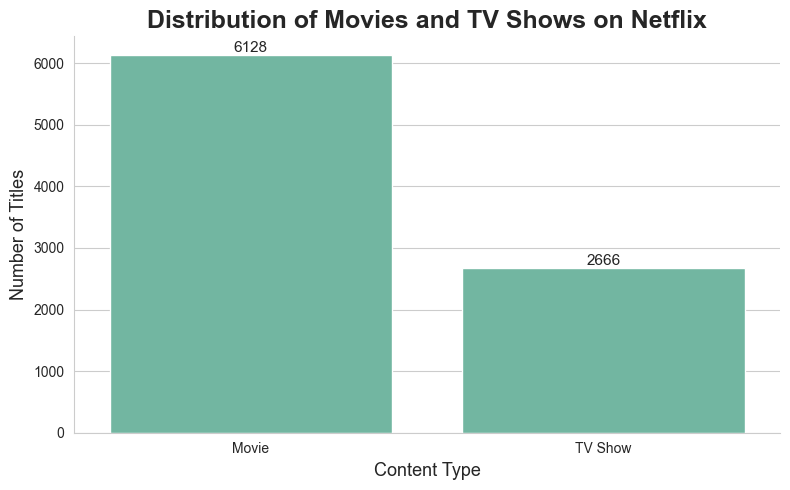

In [7]:
sns.set_style("whitegrid")  # changes the bg  into grid
sns.set_palette("Set2")    # set the color palette for the plot

plt.figure(figsize=(8, 5))   # width and height of the plot

ax = sns.countplot(data=df, x="type")

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Distribution of Movies and TV Shows on Netflix",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Content Type", fontsize=13)
plt.ylabel("Number of Titles", fontsize=13)

sns.despine()   # will remove the top and right spines from the plot
plt.tight_layout()
plt.show()

#   plot for release_year column 

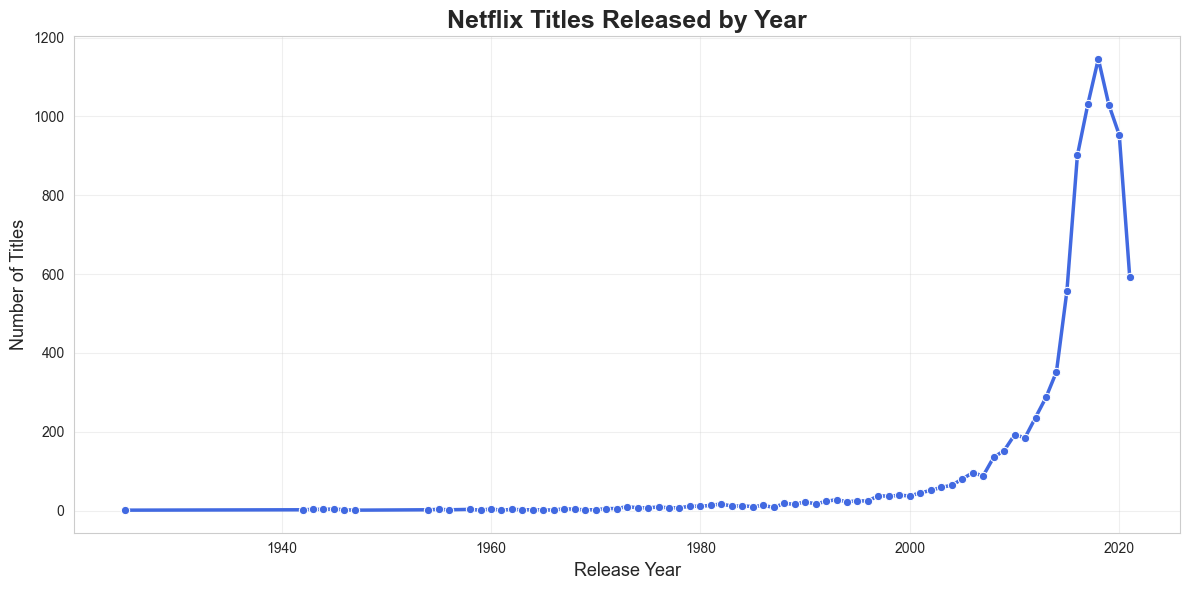

In [8]:
release_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    x=release_counts.index,
    y=release_counts.values,
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Netflix Titles Released by Year",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Release Year", fontsize=13)
plt.ylabel("Number of Titles", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Count Ratings 

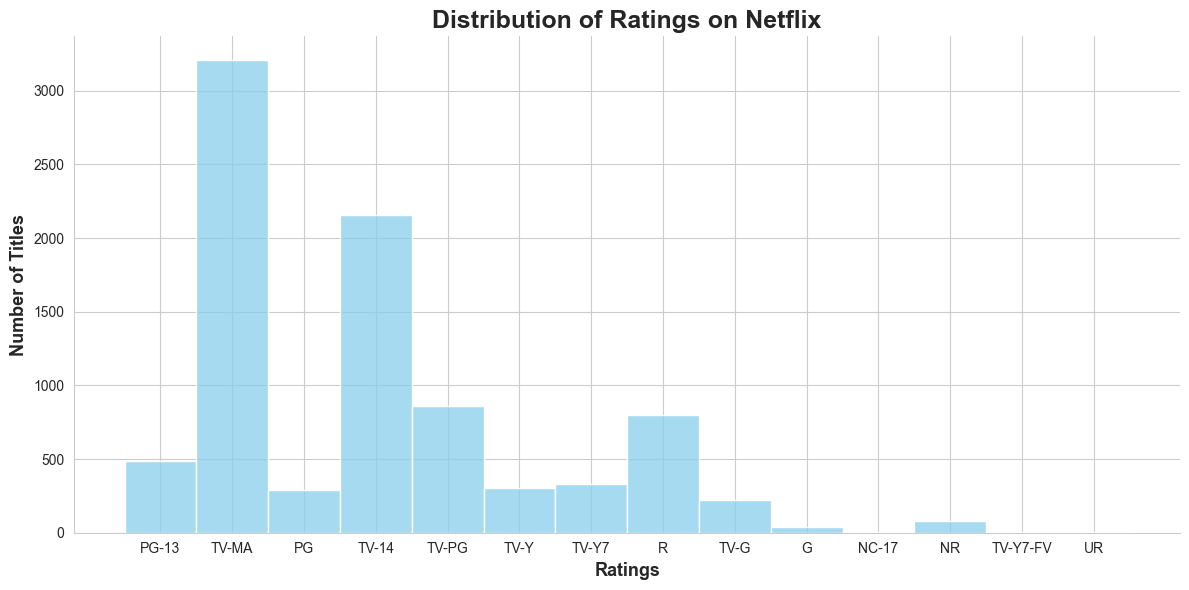

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df['rating'], color='skyblue')


plt.title("Distribution of Ratings on Netflix",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Ratings", fontsize=13, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=13, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

# Country by title releases

C:\Users\HP\AppData\Local\Temp\ipykernel_31108\2145760526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y="country",


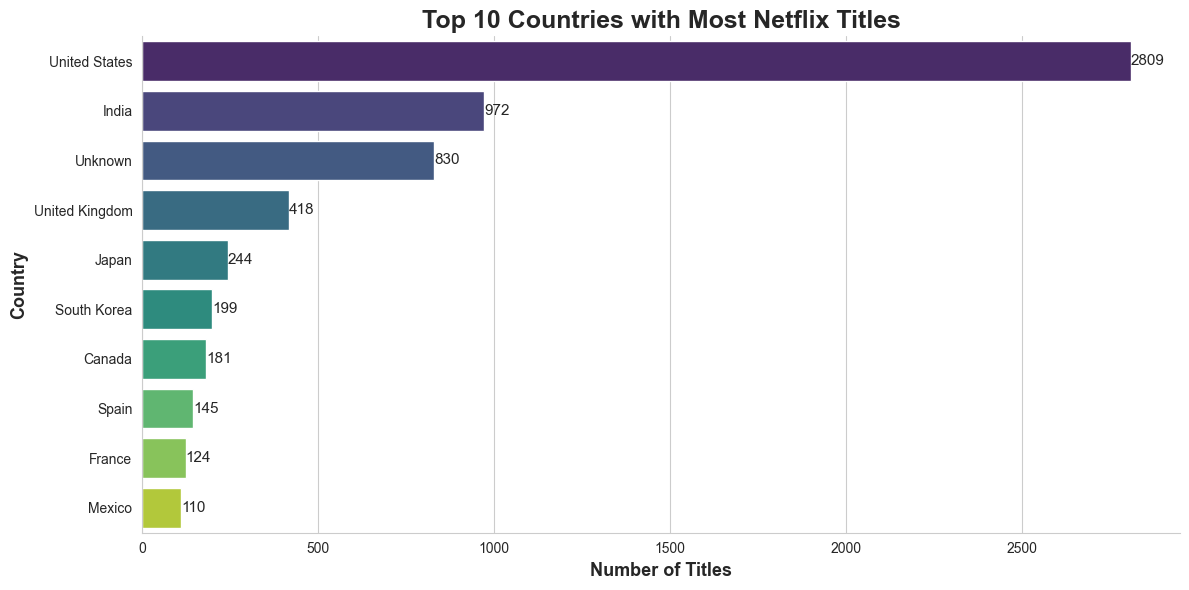

In [14]:

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, y="country",
                   order=df["country"].value_counts().head(10).index,
                   palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Top 10 Countries with Most Netflix Titles",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Number of Titles", fontsize=13, fontweight="bold")
plt.ylabel("Country", fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


# types of titles on netfix

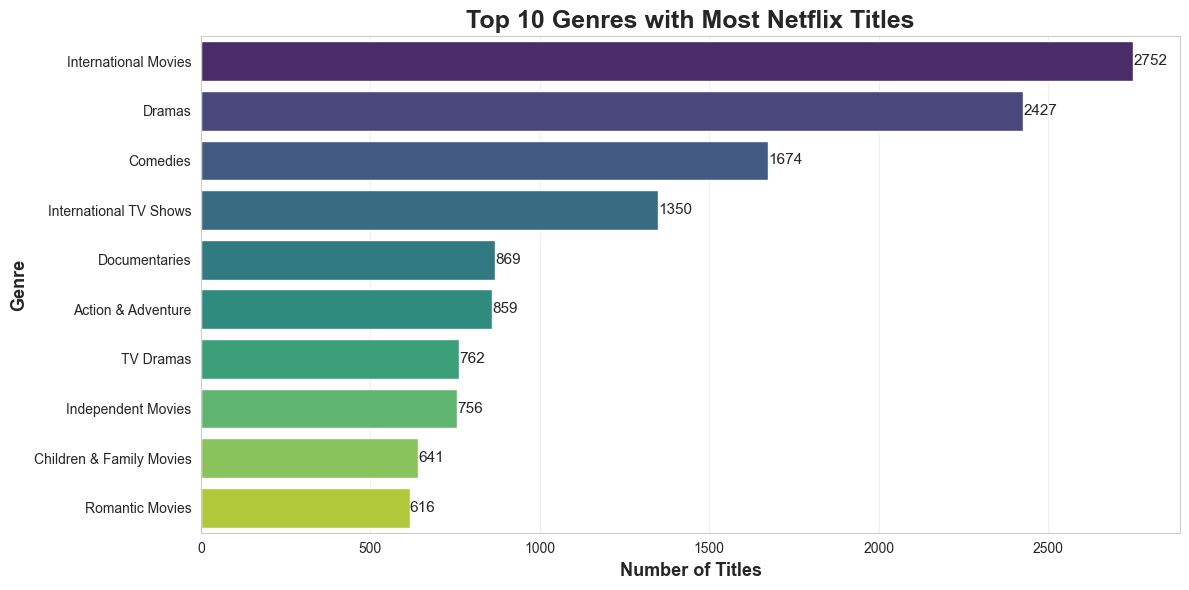

In [15]:

plt.figure(figsize=(12, 6))
abc = df['listed_in'] = df['listed_in'].str.split(
    ', ').explode().value_counts().head(10)
ax = sns.barplot(x=abc.values, y=abc.index, hue=abc.index, palette="viridis")


for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Top 10 Genres with Most Netflix Titles",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Number of Titles", fontsize=13, fontweight="bold")
plt.ylabel("Genre", fontsize=13, fontweight="bold")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# Duration Breakdown into Integers

In [18]:
movies = df[df['type'] == 'Movie'].copy()

movies['movie_duration'] = (
    movies['duration']
    .str.replace(' min', '')
    .astype(int)
)

# TV Shows
tv = df[df['type'] == 'TV Show'].copy()

tv['tv_duration'] = (
    tv['duration']
    .str.extract(r'(\d+)')
    .astype(int)
)

print(movies[['duration', 'movie_duration']].head())
print(tv[['duration', 'tv_duration']].head())

   duration  movie_duration
0    90 min              90
6    91 min              91
7   125 min             125
9   104 min             104
12  127 min             127
    duration  tv_duration
1  2 Seasons            2
2   1 Season            1
3   1 Season            1
4  2 Seasons            2
5   1 Season            1


# Bivariate Analysis( Country & type)

rating    str
type      str
dtype: object


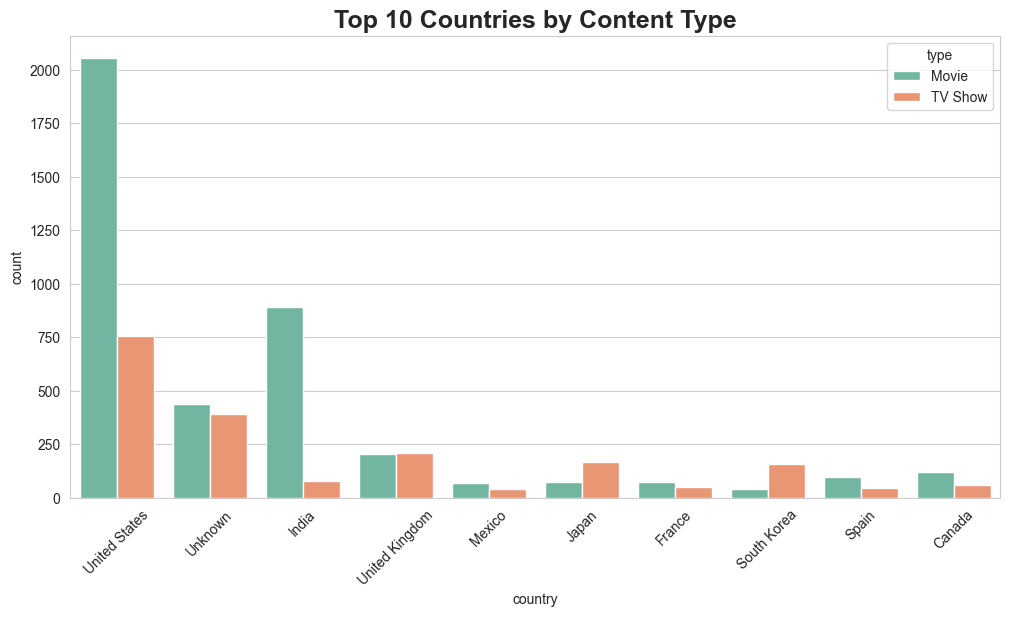

In [20]:
print(df[['rating', 'type']].dtypes)



top_countries = df['country'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df['country'].isin(top_countries)],
    x='country',
    hue='type'
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Content Type",
          fontsize=18,
          fontweight="bold")
plt.show()


# Rating vs Type ( Bivariate Analysis)

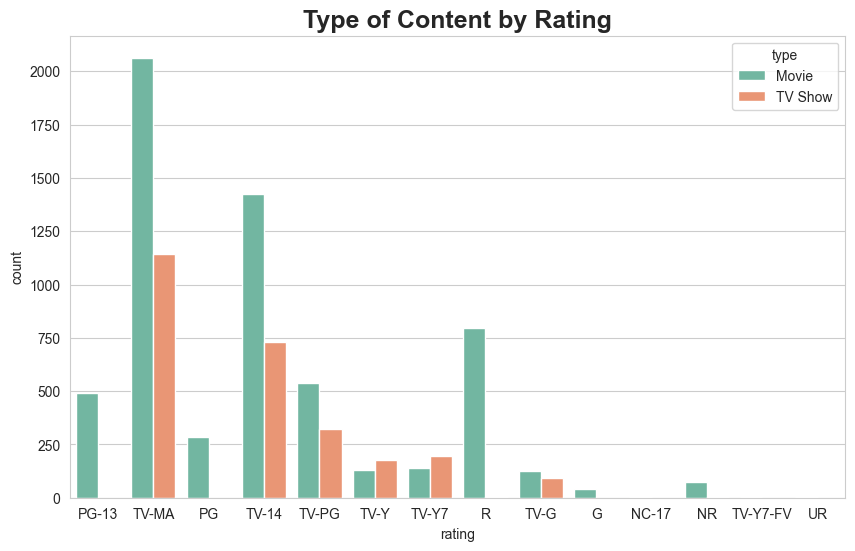

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', hue='type')
plt.title("Type of Content by Rating",
          fontsize=18,
          fontweight="bold")
plt.show()


# Released_Year vs Type ( Bivariate Analysis)

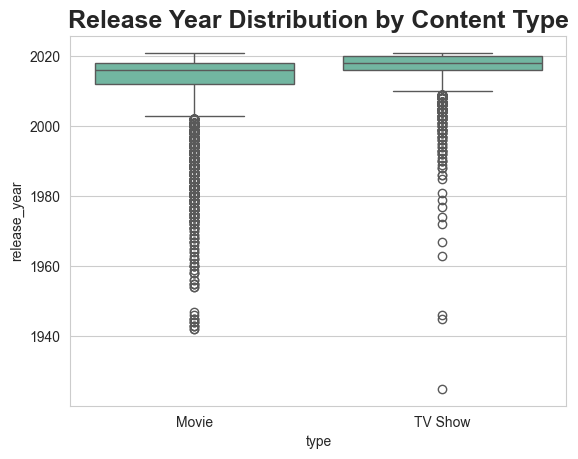

In [22]:

sns.boxplot(data=df, x='type', y='release_year')

plt.title("Release Year Distribution by Content Type",
          fontsize=18,
          fontweight="bold")

plt.show()
